# Higgs Boson Signal Classification with LightGBM
DATA 400 Individual Mini-Project (physics focus)

**Goal:** separate signal (`s`, Higgs decaying to tau tau) from background (`b`) in the ATLAS Higgs ML Challenge 2014 data, and evaluate with AUC and AMS.

**Pipeline:** load data, inspect weights, train LightGBM, evaluate (ROC and AMS), write a Kaggle-style submission.

## 1. Setup

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from src.lgbm_model import train_lgbm, plot_roc, make_submission, plot_ams_curve

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load data
Swap the `read_csv` line for your `DataLoader` call if you prefer. The full CERN file has a `KaggleSet` column (`t` = training, `b`/`v` = public/private test, `u` = unused); check the values in your copy.

In [3]:
df = pd.read_csv("data/atlas-higgs-challenge-2014-v2.csv")   # adjust path or use DataLoader

train_df = df[df["KaggleSet"] == "t"].reset_index(drop=True)
test_df  = df[df["KaggleSet"].isin(["b", "v"])].reset_index(drop=True)

print(train_df.shape, test_df.shape)
train_df.head()

(250000, 35) (550000, 35)


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s,t,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b,t,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b,t,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b,t,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b,t,6.245333


## 3. Inspect labels and event weights
Weights are per event. Background weights span a much wider range than signal weights, which is why weighting matters for both training and evaluation.

In [4]:
print(train_df["Label"].value_counts())
print()
print(train_df[["EventId", "Label", "Weight"]].head(10))

Label
b    164333
s     85667
Name: count, dtype: int64

   EventId Label    Weight
0   100000     s  0.000814
1   100001     b  0.681042
2   100002     b  0.715742
3   100003     b  1.660654
4   100004     b  1.904263
5   100005     b  0.025434
6   100006     s  0.000814
7   100007     s  0.005721
8   100008     b  1.614803
9   100009     s  0.000461


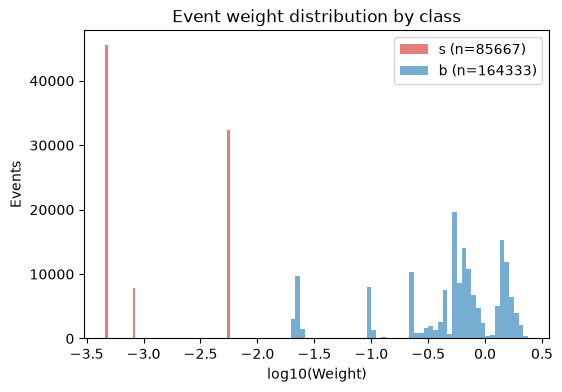

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for lab, color in [("s", "tab:red"), ("b", "tab:blue")]:
    w = train_df.loc[train_df["Label"] == lab, "Weight"]
    ax.hist(np.log10(w), bins=50, alpha=0.6, label=f"{lab} (n={len(w)})", color=color)
ax.set_xlabel("log10(Weight)")
ax.set_ylabel("Events")
ax.set_title("Event weight distribution by class")
ax.legend()
plt.show()

## 4. Train LightGBM
`train_lgbm` makes a stratified 80/20 split, trains with early stopping on weighted validation AUC, then scans thresholds for the best AMS on the validation set.

In [6]:
model, thr, val = train_lgbm(train_df)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.926806
[200]	valid_0's auc: 0.929954
[300]	valid_0's auc: 0.9311
[400]	valid_0's auc: 0.931766
[500]	valid_0's auc: 0.932193
[600]	valid_0's auc: 0.932435
[700]	valid_0's auc: 0.932585
[800]	valid_0's auc: 0.932683
[900]	valid_0's auc: 0.93279
[1000]	valid_0's auc: 0.932859
[1100]	valid_0's auc: 0.932884
[1200]	valid_0's auc: 0.932824
Early stopping, best iteration is:
[1104]	valid_0's auc: 0.932892
best iteration: 1104, threshold: 0.500, AMS: 1.130


## 5. Evaluate

### 5a. ROC curve (weighted vs. unweighted)

<Axes: title={'center': 'AMS vs. selection cut, validation split'}, xlabel='Probability threshold', ylabel='AMS'>

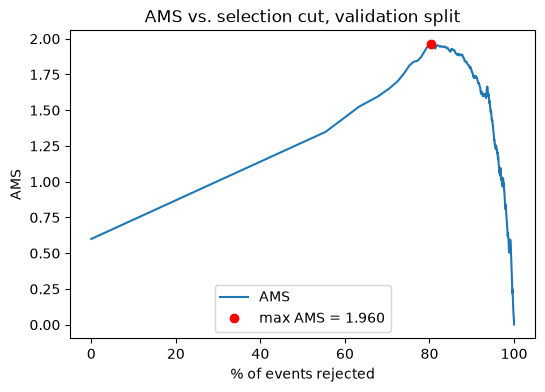

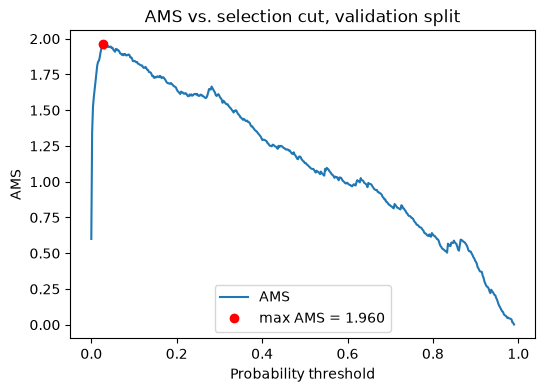

In [7]:

plot_ams_curve(val, x="rejected")    # like the paper's Fig. 10 (% of events rejected)
plot_ams_curve(val, x="threshold")   # like the paper's Fig. 7b (probability cutoff)

# Compare models trained on derived (DER) and primitive (PRI) feature families.
ams_by_group = {}
for feature_group in ("DER", "PRI"):
    _, _, ams_by_group[feature_group] = train_lgbm(
        train_df, feature_group=feature_group
    )

fig, ax = plt.subplots(figsize=(6, 4))
for feature_group, group_val in ams_by_group.items():
    plot_ams_curve(group_val, x="rejected", ax=ax, label=f"{feature_group}-only")
ax.set_title("AMS by feature family, validation split")
plt.show()

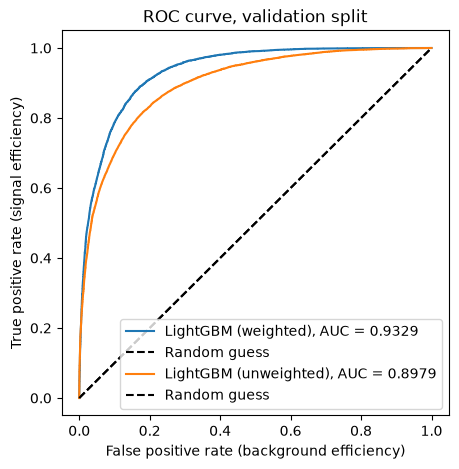

In [8]:
ax = plot_roc(val, weighted=True)
plot_roc(val, weighted=False, ax=ax)
plt.show()

### 5b. Validation predictions alongside their weights

In [9]:
pd.DataFrame(val).head(10)   # y = true label (1 = signal), p = predicted score, w = event weight

,y,p,w,w_ams
0,0,0.000010,0.992010,4.967464
1,0,0.000016,0.944251,4.728312
2,0,0.000381,1.314422,6.581936
3,0,0.000242,0.565872,2.833588
4,0,0.000008,2.106211,10.546795
5,0,0.002011,0.021757,0.108950
6,0,0.001099,0.226870,1.136046
7,0,0.058707,1.305764,6.538577
8,1,0.000072,0.005721,0.028494
9,0,0.001299,0.512740,2.567532


### 5c. Feature importance

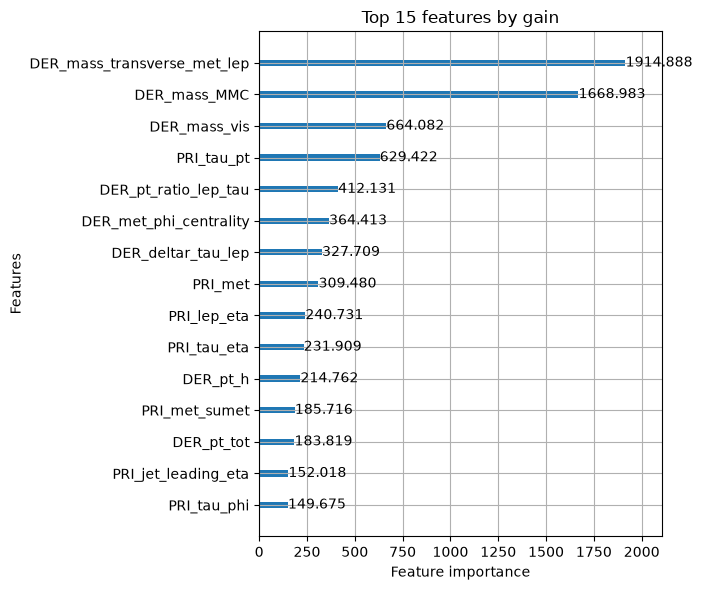

In [10]:
lgb.plot_importance(model, importance_type="gain", max_num_features=15, figsize=(7, 6))
plt.title("Top 15 features by gain")
plt.tight_layout()
plt.show()

## 6. Kaggle-style submission
The test rows have no usable labels for scoring here, so this file only contains `EventId`, `RankOrder`, and `Class`.

In [11]:
submission = make_submission(model, test_df, thr, path="submission.csv")
submission.head()

,EventId,RankOrder,Class
0,350000,545862,b
1,350001,335827,b
2,350002,187838,b
3,350003,24410,b
4,350004,414924,b


## 7. Notes and next steps
- Compare against the XGBoost baseline on the same split (AMS, AUC, training time).
- Record the best AMS threshold and best iteration reported above in the write-up.
- Optional: early stop on AMS with a custom `feval` instead of AUC and compare.